# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Introduction
This notebook is part of my Data Science & Analytics Internship at DevelopersHub Corporation. The objective of this task is to build a machine learning model that predicts whether a bank customer will subscribe to a term deposit as a result of a marketing campaign, and to explain individual model predictions using SHAP.

## Problem Statement
I am working with the Bank Marketing Dataset from the UCI Machine Learning Repository. It contains 45,211 customer records with 17 columns including age, job, marital status, education, account balance, call duration, and previous campaign outcomes. The target variable is y — whether a customer subscribed to a term deposit (yes or no). The goal is to clean and encode the data, explore patterns through visualization, train classification models, evaluate them using standard metrics, and interpret predictions using SHAP.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, roc_curve, auc)
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df = pd.read_csv('bank-full.csv', sep=';')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
print("Missing Values")
print(df.isnull().sum())

print("Target Variable Distribution")
print(df['y'].value_counts())

Missing Values
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Target Variable Distribution
y
no     39922
yes     5289
Name: count, dtype: int64


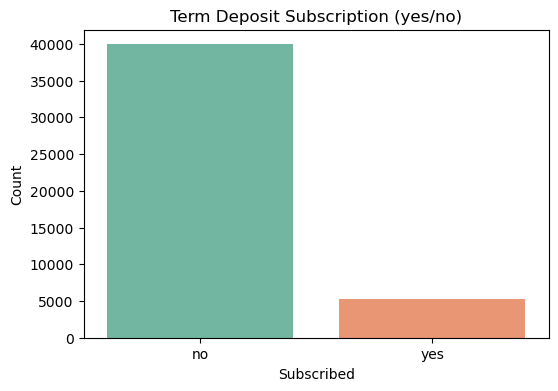

In [7]:
# EDA
# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Term Deposit Subscription (yes/no)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()


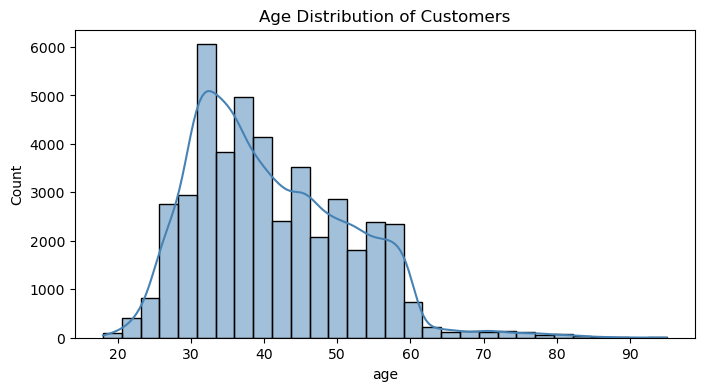

In [8]:
# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Customers')
plt.show()


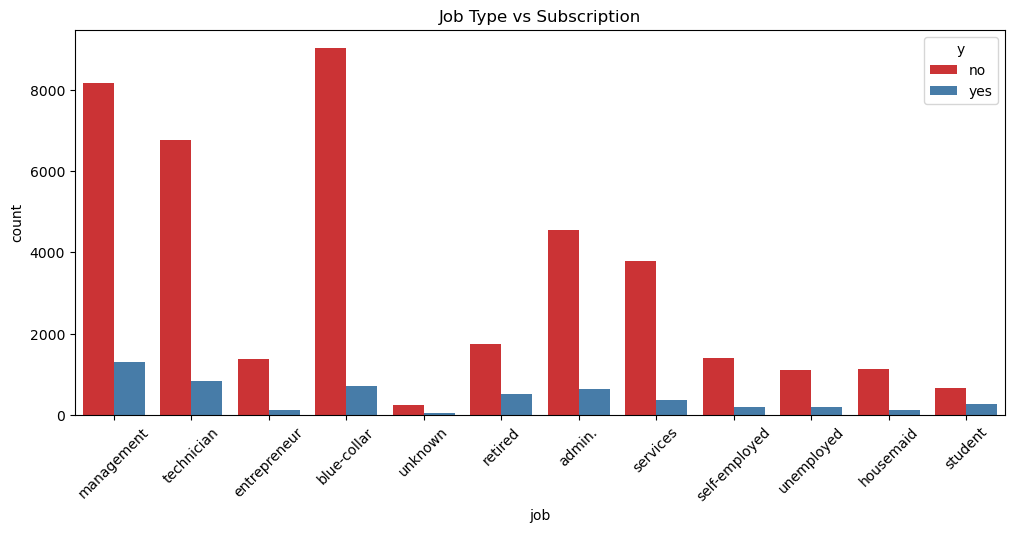

In [9]:
# Job vs Subscription
plt.figure(figsize=(12,5))
sns.countplot(x='job', hue='y', data=df, palette='Set1')
plt.xticks(rotation=45)
plt.title('Job Type vs Subscription')
plt.show()


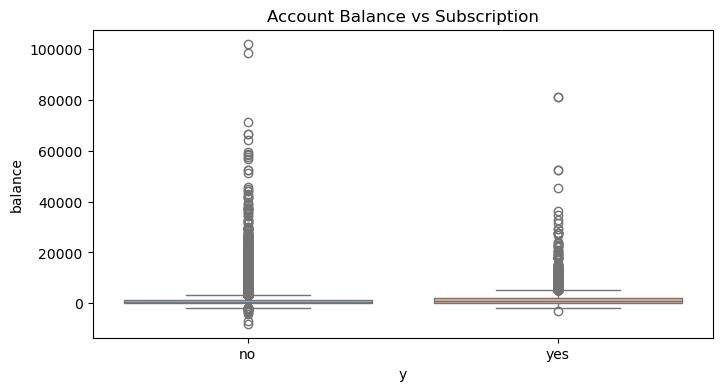

In [10]:
# Balance distribution
plt.figure(figsize=(8,4))
sns.boxplot(x='y', y='balance', data=df, palette='pastel')
plt.title('Account Balance vs Subscription')
plt.show()

In [11]:
# Copy dataframe
df_encoded = df.copy()

# Encoding
le = LabelEncoder()
categorical_cols = df_encoded.select_dtypes(include='object').columns

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
print(df_encoded.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      8       261         1     -1         0         3  0  
1    5      8       151         1     -1         0         3  0  
2    5      8        76         1     -1         0         3  0  
3    5      8        92         1     -1         0         3  0  
4    5      8       198         1     -1         0         3  0  


In [12]:
# Prepare data for ML
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (36168, 16)
Testing set size: (9043, 16)


In [13]:
# Logistic Regression Model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.57      0.21      0.30      1091

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.62      9043
weighted avg       0.86      0.89      0.86      9043

F1 Score: 0.3042895442359249


In [14]:
# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043

F1 Score: 0.4994438264738598


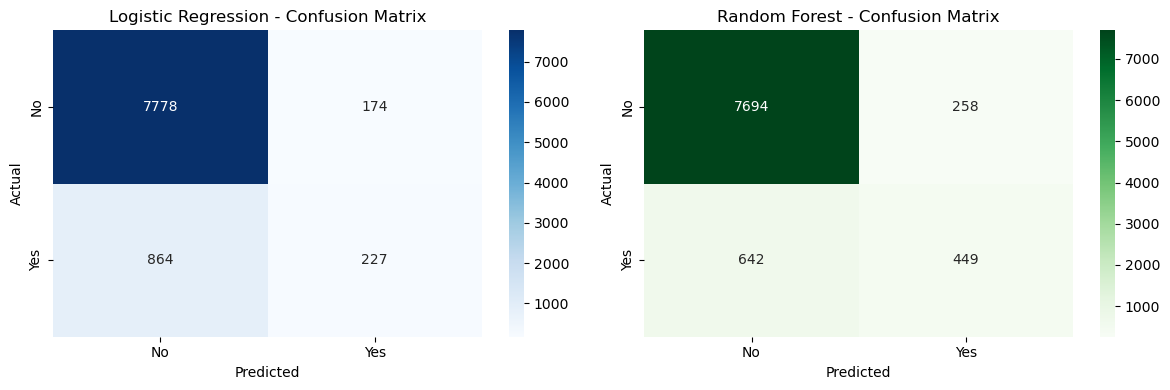

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1],
            cmap='Greens', xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

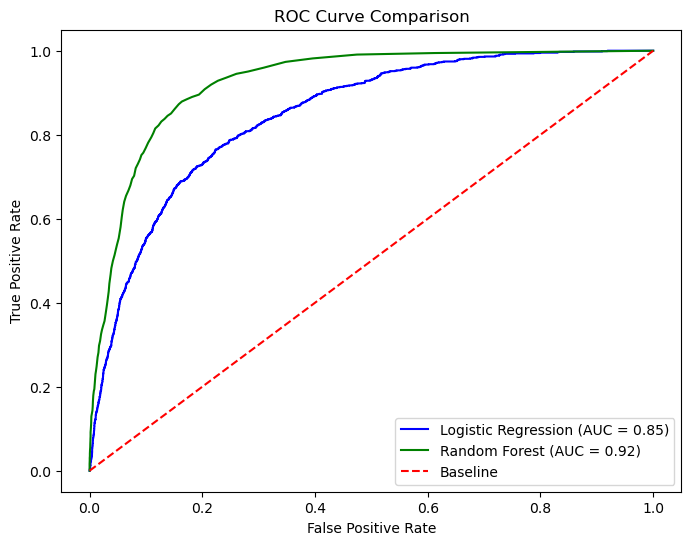

In [16]:
# ROC Curve for both models
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC
y_prob_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='blue')

# Random Forest ROC
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='green')

# Baseline
ax.plot([0,1], [0,1], 'k--', label='Baseline', color='red')
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()

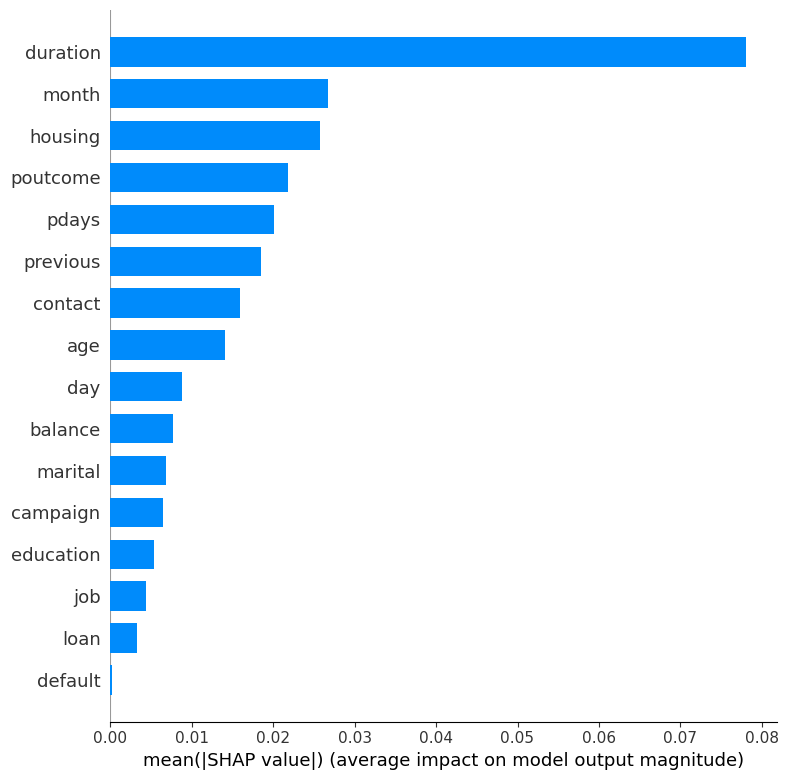

In [17]:
# SHAP 
X_sample = X_test.iloc[:50]

explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_sample)

# Fix for newer SHAP versions
if isinstance(shap_vals, list):
    shap_vals_plot = shap_vals[1]
else:
    shap_vals_plot = shap_vals[:, :, 1]

# Bar chart of feature importance
shap.summary_plot(shap_vals_plot, X_sample,
                  plot_type="bar",
                  show=True)

## Conclusion and Key Insights
The Bank Marketing dataset contained 45,211 records with a notable class imbalance — the majority of customers did not subscribe, which affected model behaviour toward the minority class.
Visualizations confirmed the following patterns:

Term Deposit Subscription Distribution showed a strong class imbalance, with significantly more no responses than yes. This means both models were trained on unequal class proportions.
Age Distribution revealed that the customer base skews toward working-age adults, with most customers in the 30–50 range. A smaller peak appears around retirement age, where subscription rates tend to be higher.
Job Type vs Subscription showed that students and retired customers had relatively higher subscription rates compared to blue-collar or service workers, suggesting occupation is a meaningful feature.
Account Balance vs Subscription showed that customers who subscribed generally had higher median balances, indicating that financial stability correlates with term deposit uptake.

Random Forest outperformed Logistic Regression with a higher F1-Score and AUC on the test set. SHAP analysis identified duration (call duration) as the most influential feature — longer calls strongly increased the probability of subscription. Other important features included balance, age, and campaign (number of contacts during the campaign).
## Recommendation: 
Prioritise customers with longer call engagement and higher account balances in future campaigns, and limit repeated contact attempts as excessive outreach appears to reduce subscription likelihood.